In [1]:
import dpluspy 
import numpy as np
import pandas

In [2]:
# Load tables of parameters and likelihoods
bher_tables = []
for j in range(3):
    bher_tables += [dpluspy.inference.load_param_table(f"models/model_{j}_params.yaml",
        [f"fitted_models/model_{j}_Bherer_fit_{i}.yaml" for i in range(30)])]
bher_table = pandas.concat(bher_tables)
    
zhou_tables = []
for j in range(3):
    zhou_tables += [dpluspy.inference.load_param_table(f"models/model_{j}_params.yaml",
        [f"fitted_models/model_{j}_ZhouJHS_fit_{i}.yaml" for i in range(30)])]
zhou_table = pandas.concat(zhou_tables)

Could not load parameters for fitted_models/model_0_Bherer_fit_0.yaml, models/model_0_params.yaml
Could not load parameters for fitted_models/model_0_Bherer_fit_16.yaml, models/model_0_params.yaml
Could not load parameters for fitted_models/model_1_Bherer_fit_1.yaml, models/model_1_params.yaml
Could not load parameters for fitted_models/model_1_Bherer_fit_10.yaml, models/model_1_params.yaml
Could not load parameters for fitted_models/model_1_Bherer_fit_17.yaml, models/model_1_params.yaml
Could not load parameters for fitted_models/model_1_Bherer_fit_21.yaml, models/model_1_params.yaml
Could not load parameters for fitted_models/model_1_Bherer_fit_26.yaml, models/model_1_params.yaml
Could not load parameters for fitted_models/model_2_Bherer_fit_1.yaml, models/model_2_params.yaml
Could not load parameters for fitted_models/model_2_Bherer_fit_2.yaml, models/model_2_params.yaml
Could not load parameters for fitted_models/model_2_Bherer_fit_8.yaml, models/model_2_params.yaml
Could not load 

In [3]:
print("Bherer")
for i in range(3):
    print(i, np.max(bher_table[[f"model_{i}" in x for x in bher_table["fname"]]]["ll"]))

print("\nZhou")
for i in range(3):
    print(i, np.max(zhou_table[[f"model_{i}" in x for x in zhou_table["fname"]]]["ll"]))

Bherer
0 -194.4609334438468
1 -167.08292991484188
2 -142.23929659561918

Zhou
0 -209.72683574715336
1 -211.99612732204508
2 -128.57506531798086


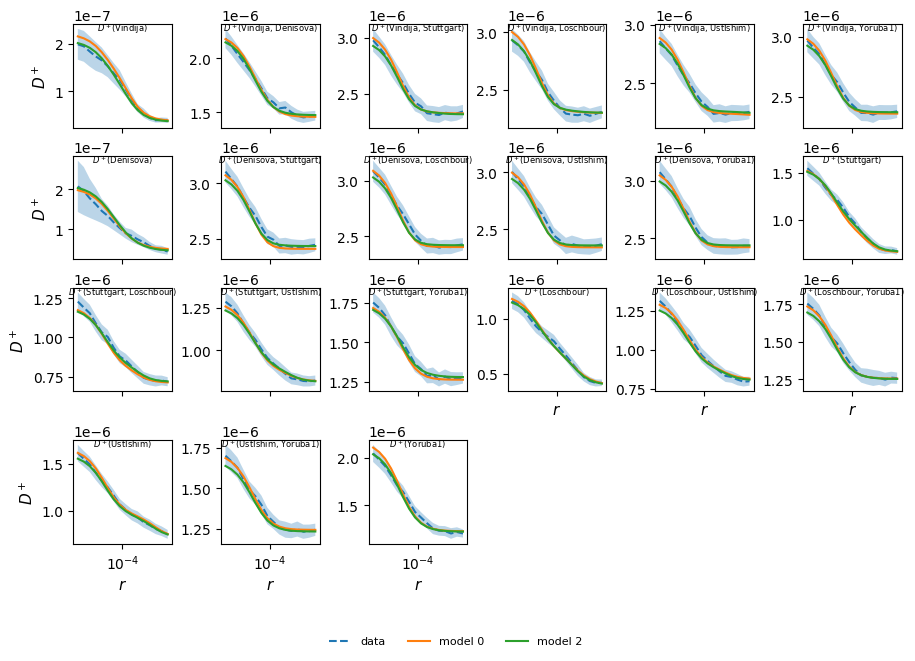

In [9]:
graph_fname_0 = "fitted_models/model_0_Bherer_fit_4.yaml"
graph_fname_2 = "fitted_models/model_2_Bherer_fit_12.yaml"
data_fname = "../../data/stats_Bherer_weighted.pkl"
data = dpluspy.inference.load_stats(data_fname, graph=graph_fname_0, return_dict=1)
model_0 = dpluspy.inference.compute_bin_stats(graph_fname_0, sampled_demes=data["pop_ids"],
    bins=data["bins"], u=1.3e-8)
model_2 = dpluspy.inference.compute_bin_stats(graph_fname_2, sampled_demes=data["pop_ids"],
    bins=data["bins"], u=1.3e-8)
dpluspy.plotting.plot_D_plus_curves(
    models=[model_0, model_2],
    means=data["means"],
    varcovs=data["varcovs"],
    bins=data["bins"],
    pop_ids=data["pop_ids"],
    labels=["data", "model 0", "model 2"],
    ax_size=1.5,
    cols=6
)